# After the Revolution: A Data Story of Tunisia (2000–2023)

Tunisia entered the 21st century as one of Africa's most stable and promising economies. By 2023, it had lived through a popular revolution, a devastating terrorism crisis, an IMF bailout, and a global pandemic. This notebook uses World Bank data to trace what happened to Tunisia's economy across those two decades — and tries to understand why.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [21]:
#load tunisia data
tunisia_data = pd.read_csv("../data/TUN.csv",skiprows=4,index_col=3)
tunisia_data.head()

,Country Name,Country Code,Indicator Name,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Indicator Code,,,,,,,,,,,,,,,,,,,,,
SL.UEM.TOTL.FE.NE.ZS,Tunisia,TUN,"Unemployment, female (% of female labor force)...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.629,22.761,25.212,NaN,9.568,20.153,20.450,NaN,NaN,NaN
SL.UEM.NEET.MA.ME.ZS,Tunisia,TUN,"Share of youth not in education, employment or...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,26.386,26.121,26.986,27.485,26.410,25.371,24.417,24.521,24.625,NaN
SL.UEM.INTM.MA.ZS,Tunisia,TUN,"Unemployment with intermediate education, male...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.491,NaN,17.533,NaN,14.711,12.153,10.896,NaN,NaN,NaN
SL.UEM.BASC.FE.ZS,Tunisia,TUN,"Unemployment with basic education, female (% o...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.563,NaN,14.669,NaN,4.249,12.581,13.293,NaN,NaN,NaN
SL.UEM.1524.ZS,Tunisia,TUN,"Unemployment, youth total (% of total labor fo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,35.315,34.877,37.867,41.242,39.309,37.826,38.484,38.850,38.075,NaN


In [22]:
tunisia_data.drop(columns=["Country Name","Country Code","Indicator Name"],inplace=True)
tunisia_data.head()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Indicator Code,,,,,,,,,,,,,,,,,,,,,
SL.UEM.TOTL.FE.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.629,22.761,25.212,NaN,9.568,20.153,20.450,NaN,NaN,NaN
SL.UEM.NEET.MA.ME.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,26.386,26.121,26.986,27.485,26.410,25.371,24.417,24.521,24.625,NaN
SL.UEM.INTM.MA.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.491,NaN,17.533,NaN,14.711,12.153,10.896,NaN,NaN,NaN
SL.UEM.BASC.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.563,NaN,14.669,NaN,4.249,12.581,13.293,NaN,NaN,NaN
SL.UEM.1524.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,35.315,34.877,37.867,41.242,39.309,37.826,38.484,38.850,38.075,NaN


In [23]:
tunisia_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1486 entries, SL.UEM.TOTL.FE.NE.ZS to AG.CON.FERT.ZS
Data columns (total 67 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   1960         138 non-null    float64
 1   1961         181 non-null    float64
 2   1962         201 non-null    float64
 3   1963         210 non-null    float64
 4   1964         212 non-null    float64
 5   1965         307 non-null    float64
 6   1966         317 non-null    float64
 7   1967         314 non-null    float64
 8   1968         316 non-null    float64
 9   1969         322 non-null    float64
 10  1970         417 non-null    float64
 11  1971         459 non-null    float64
 12  1972         490 non-null    float64
 13  1973         500 non-null    float64
 14  1974         486 non-null    float64
 15  1975         525 non-null    float64
 16  1976         576 non-null    float64
 17  1977         579 non-null    float64
 18  1978         601 non-nul

In [24]:
tunisia_data.describe(include="all")

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
count,1.380000e+02,1.810000e+02,2.010000e+02,2.100000e+02,2.120000e+02,3.070000e+02,3.170000e+02,3.140000e+02,3.160000e+02,3.220000e+02,...,9.470000e+02,9.440000e+02,9.290000e+02,9.300000e+02,9.550000e+02,8.470000e+02,8.200000e+02,6.100000e+02,8.600000e+01,0.0
mean,1.554749e+07,1.307128e+08,1.112545e+08,1.056120e+08,9.985464e+07,4.121239e+08,4.122439e+08,4.216757e+08,4.434730e+08,4.495498e+08,...,4.392175e+09,4.631896e+09,4.868248e+09,4.565295e+09,4.832782e+09,5.633460e+09,6.350146e+09,8.842549e+09,1.517425e+08,NaN
std,5.690859e+07,1.007257e+09,9.120529e+08,8.022013e+08,7.615339e+08,1.493092e+09,1.529586e+09,1.544430e+09,1.653257e+09,1.676846e+09,...,1.747961e+10,1.852325e+10,1.946388e+10,1.857442e+10,1.975818e+10,2.218382e+10,2.551550e+10,3.061693e+10,1.295805e+09,NaN
min,-6.133400e+04,-6.136900e+04,-6.126000e+04,-6.050500e+04,-2.334000e+06,-2.438095e+07,-2.666667e+07,-3.695238e+07,-4.990476e+07,-5.580952e+07,...,-1.261640e+10,-1.457550e+10,-1.282810e+10,-9.978100e+09,-1.325050e+10,-1.874680e+10,-1.222791e+11,-1.215539e+11,-1.452300e+04,NaN
25%,2.502680e+00,4.134530e+00,3.870868e+00,4.478737e+00,4.137500e+00,7.393390e+00,6.485757e+00,6.713115e+00,6.761140e+00,6.853901e+00,...,7.380444e+00,6.196718e+00,6.885857e+00,5.854585e+00,6.515277e+00,8.160219e+00,7.850277e+00,6.399709e+00,1.255240e+01,NaN
50%,1.571165e+01,2.820895e+01,2.426060e+01,3.224494e+01,2.918989e+01,6.744186e+01,5.100000e+01,5.519543e+01,5.172972e+01,5.500705e+01,...,4.875523e+01,5.020425e+01,4.054000e+01,4.640537e+01,3.800000e+01,5.594600e+01,5.307995e+01,3.918610e+01,2.763298e+01,NaN
75%,1.475502e+05,1.553600e+05,2.621800e+04,7.916575e+04,3.314725e+04,4.409762e+07,2.410000e+07,3.757500e+07,3.245700e+07,2.736250e+07,...,5.244000e+04,8.971125e+04,1.636100e+05,5.732550e+04,1.328716e+04,1.443195e+05,3.269527e+05,1.930092e+06,4.994336e+01,NaN
max,4.095727e+08,1.204012e+10,1.148747e+10,1.025440e+10,9.774912e+09,1.209032e+10,1.300872e+10,1.296442e+10,1.440007e+10,1.436972e+10,...,1.509369e+11,1.548718e+11,1.572724e+11,1.431570e+11,1.499370e+11,1.650476e+11,2.229326e+11,2.262085e+11,1.198272e+10,NaN


In [25]:
print("null values in each column:",tunisia_data.isnull().sum())

null values in each column: 1960           1348
1961           1305
1962           1285
1963           1276
1964           1274
               ... 
2022            639
2023            666
2024            876
2025           1400
Unnamed: 70    1486
Length: 67, dtype: int64


In [26]:
indicators = {
    "MS.MIL.XPND.ZS" : "military_expenditure",
    "NY.GDP.PCAP.CD": "gdp_per_capita",
    "SL.UEM.TOTL.ZS": "unemployment",
    "SL.UEM.1524.ZS": "youth_unemployment",
    "FP.CPI.TOTL.ZG": "inflation",
    "ST.INT.XPND.CD" : "tourism_expenditure",
    "ST.INT.ARVL" : "tourism_arrivals",
    "ST.INT.RCPT.CD" : "tourism_revenue",
    "SH.XPD.CHEX.GD.ZS" : "health_expenditure",
    "SE.XPD.TOTL.GD.ZS" : "education_expenditure",
    "NE.EXP.GNFS.ZS": "exports",
    "NE.IMP.GNFS.ZS": "imports",
    "NE.RSB.GNFS.ZS": "trade_balance",
}

#delete all rows beside the indicators we are interested in
tunisia_data = tunisia_data.loc[indicators.keys()]
tunisia_data.index = tunisia_data.index.map(indicators)
tunisia_data

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Indicator Code,,,,,,,,,,,,,,,,,,,,,
military_expenditure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.073337e+00,6.890157e+00,8.070219e+00,7.855481e+00,7.919698,7.046129,7.001232,7.267845,NaN,NaN
gdp_per_capita,NaN,200.671835,201.419167,231.919408,228.484794,217.269013,223.750680,228.044765,248.912255,257.738833,...,3.619032e+03,3.628104e+03,3.528872e+03,3.548654e+03,3906.939263,3707.292834,3951.116834,4181.137893,NaN,NaN
unemployment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.533000e+01,1.545900e+01,1.715300e+01,1.765100e+01,16.632000,15.300000,15.106000,15.341000,15.108,NaN
youth_unemployment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.531500e+01,3.487700e+01,3.786700e+01,4.124200e+01,39.309000,37.826000,38.484000,38.850000,38.075,NaN
inflation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.308848e+00,7.307592e+00,6.720075e+00,5.634151e+00,5.706350,8.306461,9.328996,7.206617,NaN,NaN
tourism_expenditure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.710000e+08,9.540000e+08,8.890000e+08,4.070000e+08,NaN,NaN,NaN,NaN,NaN,NaN
tourism_arrivals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.052000e+06,8.299000e+06,9.429000e+06,2.012000e+06,NaN,NaN,NaN,NaN,NaN,NaN
tourism_revenue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.782000e+09,2.320000e+09,2.683000e+09,1.007000e+09,NaN,NaN,NaN,NaN,NaN,NaN
health_expenditure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.185575e+00,5.937519e+00,6.024612e+00,7.056126e+00,7.341840,7.512707,7.985379,NaN,NaN,NaN


## Chapter 1 : PRE revelution era

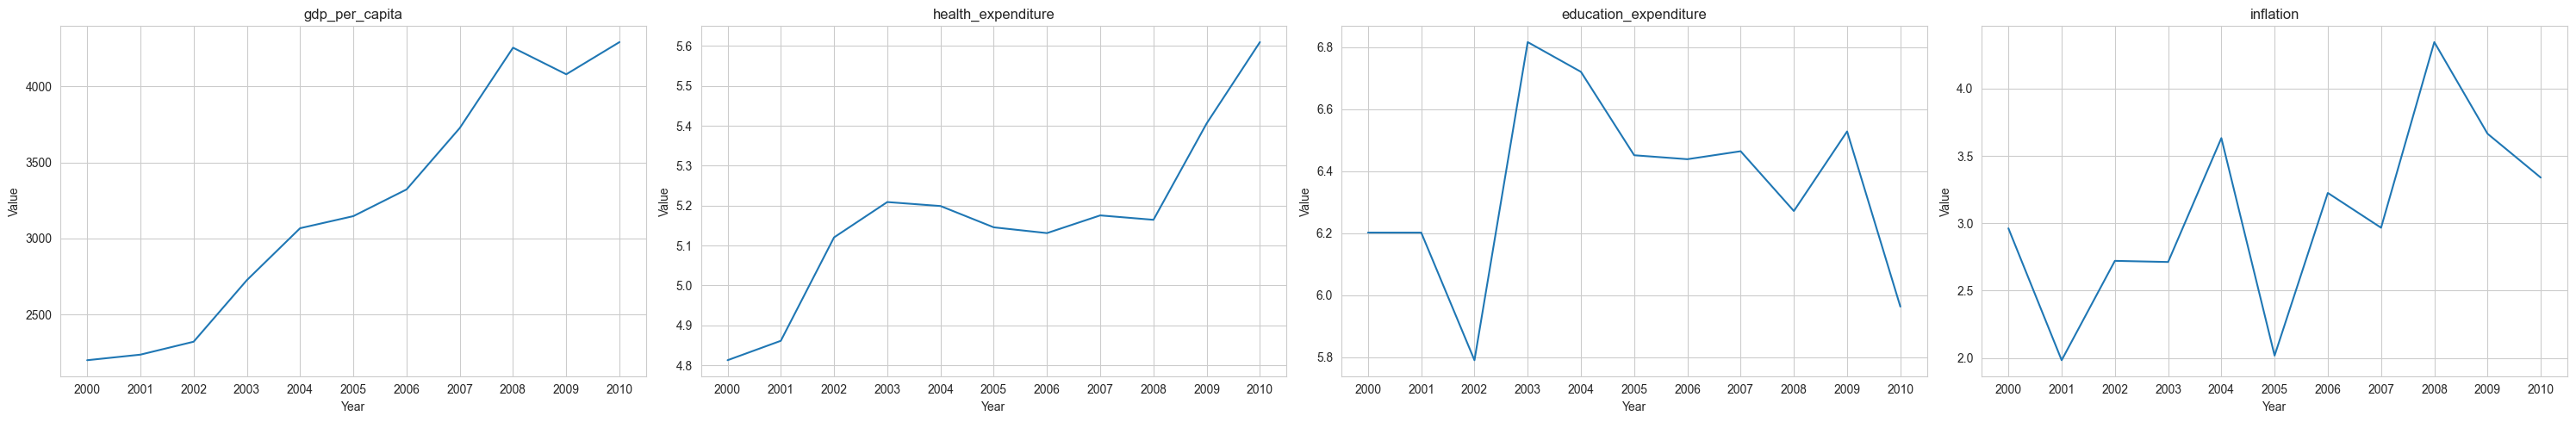

In [27]:
# tunisia gpd per capita + health expenditure +education expenditure + inflation
pre_rev_indicators = ["gdp_per_capita","health_expenditure","education_expenditure","inflation"]
pre_rev_data = tunisia_data.loc[pre_rev_indicators]
fig, axes = plt.subplots(1, 4, figsize=(30, 5))
for i, indicator in enumerate(pre_rev_indicators):
    sns.lineplot(data=pre_rev_data.loc[indicator]["2000":"2010"], ax=axes[i])
    axes[i].set_title(indicator)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Value")
plt.tight_layout()
plt.show()



Pre-revolution Tunisia showed a steady rise in GDP throughout the 2000s, briefly crossing the $4,000 per capita mark. Government health spending was also increasing, though the climb was slow. Inflation remained relatively unstable during this period, and education spending didn't follow any clear trend either — two warning signs that the growth wasn't as solid as it looked on the surface.

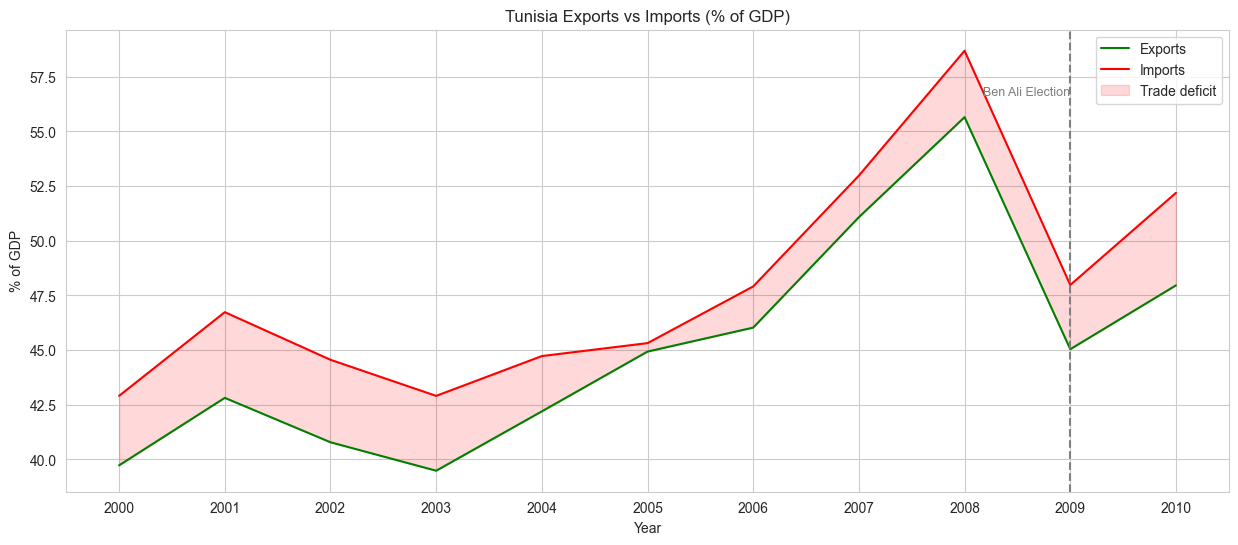

In [38]:
plt.figure(figsize=(15, 6))

exports = tunisia_data.loc["exports"]["2000":"2010"]
imports = tunisia_data.loc["imports"]["2000":"2010"]

sns.lineplot(data=exports, label="Exports", color="green")
sns.lineplot(data=imports, label="Imports", color="red")

# shade the gap between them — this is the trade deficit
plt.fill_between(exports.index, exports.values, imports.values,
                 where=(imports.values > exports.values),
                 alpha=0.15, color="red", label="Trade deficit")

plt.axvline(x="2009", color="gray", linestyle="--")
plt.text("2009", plt.ylim()[1]*0.95, "Ben Ali Election", color="gray", fontsize=9, ha="right")


plt.title("Tunisia Exports vs Imports (% of GDP)")
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.legend()

On the surface, Tunisia's political scene appeared stable but the economic cracks were starting to show. After Ben Ali's reelection in 2009, the trade deficit widened and ordinary Tunisians felt the pressure through rising prices. Many historians argue that the first spark of the revolution can be traced back to 2009: the regime was losing its grip on the economy, still recovering from the 2008 global financial shock, while simultaneously cracking down on basic freedoms. Injustice and police brutality did the rest.

## Chapter 2 : The Revolution (2011–2013)

Text(0, 0.5, 'GDP per capita (current US$)')

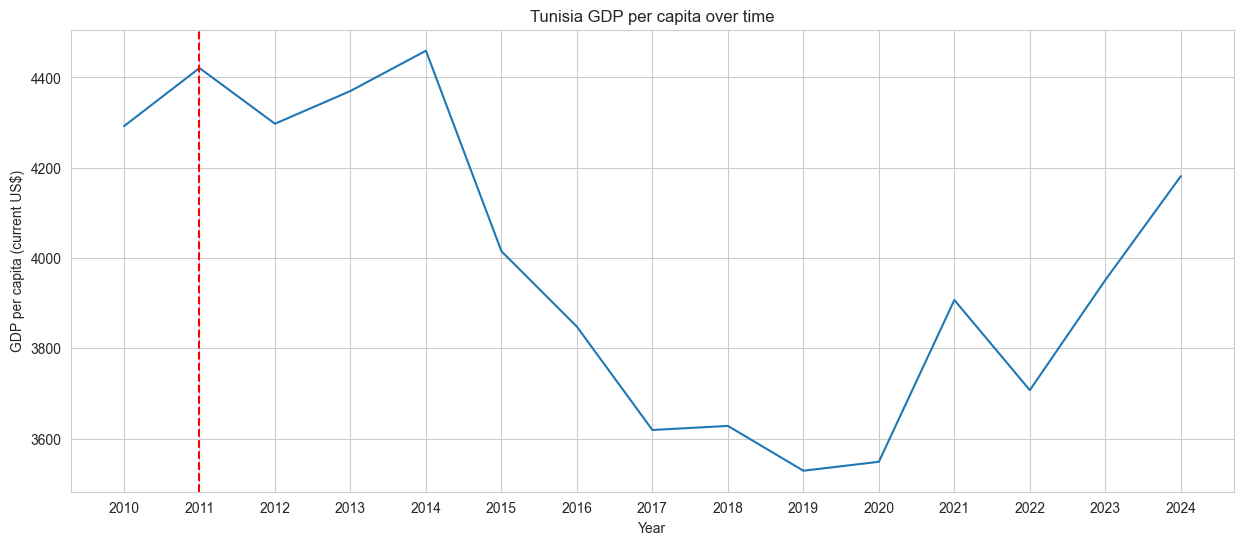

In [40]:
# tunisia gpd per capita over time
plt.figure(figsize=(15,6))
data = tunisia_data.loc["gdp_per_capita"]["2010":] 
sns.lineplot(data=data)
plt.axvline(x="2011", color='red', linestyle='--')
plt.title("Tunisia GDP per capita over time")   
plt.xlabel("Year")
plt.ylabel("GDP per capita (current US$)")



In the first years after the revolution, a transitional government took over and the economic impact was real but not catastrophic. GDP dipped briefly then recovered, even reaching an all-time high in 2014 partly because the international community rallied around the newly democratic Tunisia, offering aid and investment. For a moment, it seemed like the country had made it through the hardest part.

## Chapter 3 : The Terrorism Crisis (2014–2016)

Then came 2015. The GDP had already started softening in 2014, driven by regional instability — especially in Libya, one of Tunisia's biggest trading partners. But the Bardo Museum attack in March 2015, followed by the Sousse beach attack in June, delivered the real blow. Tourism collapsed almost overnight, and for a country that depends heavily on tourism for foreign currency, the consequences were severe.

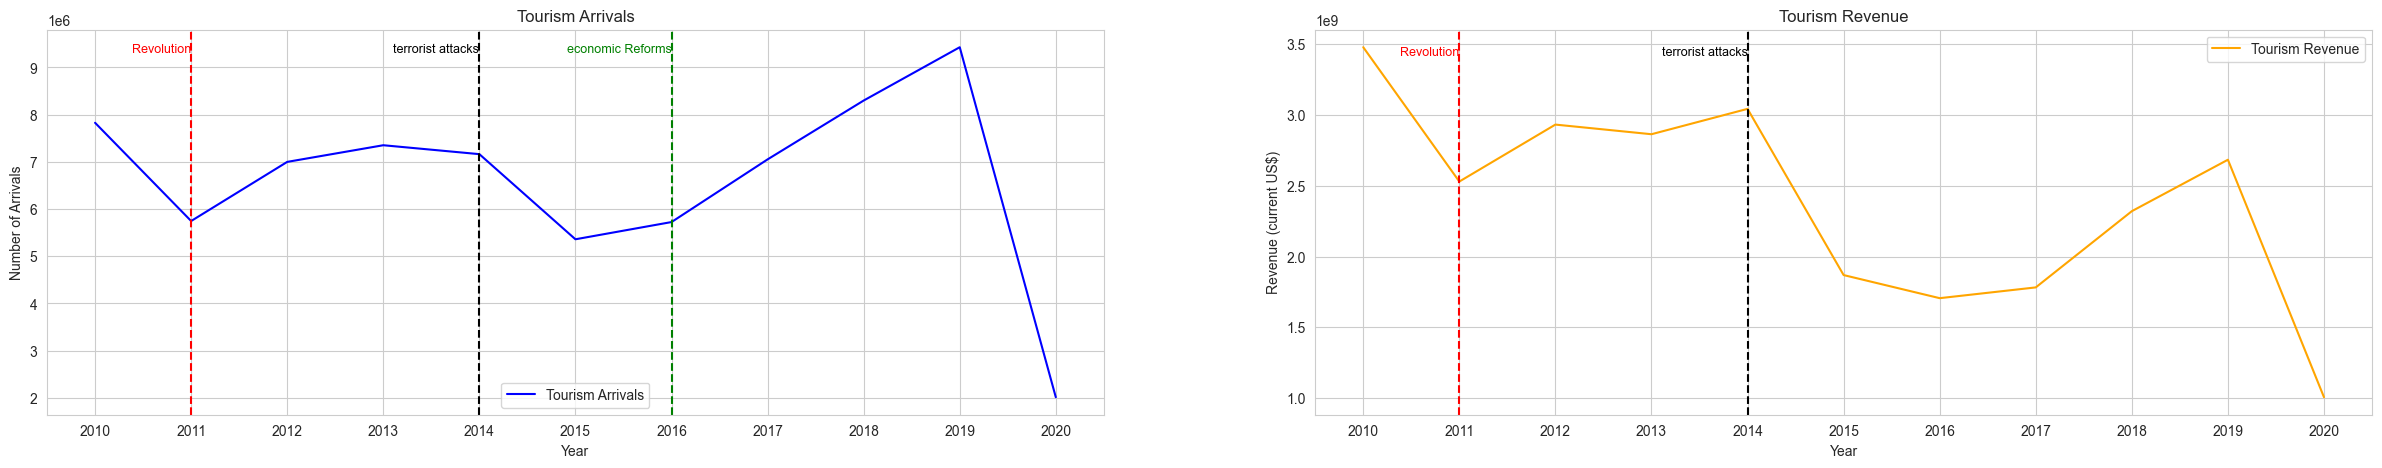

In [51]:
tourism_indicators_vs_gdp = ["tourism_arrivals","tourism_revenue","gdp_per_capita"]

figure, axes = plt.subplots(1, 2, figsize=(30, 5))
tourism_arrivals = tunisia_data.loc["tourism_arrivals"]["2010":]
tourism_revenue = tunisia_data.loc["tourism_revenue"]["2010":]
axes[0].plot(tourism_arrivals.index, tourism_arrivals.values, label="Tourism Arrivals", color="blue")
axes[0].axvline(x="2011", color='red', linestyle='--')
axes[0].text("2011", axes[0].get_ylim()[1]*0.95, "Revolution", color='red', fontsize=9, ha="right")
axes[0].axvline(x="2014", color='black', linestyle='--')
axes[0].text("2014", axes[0].get_ylim()[1]*0.95, "terrorist attacks", color='black', fontsize=9, ha="right")
axes[0].axvline(x="2016", color='green', linestyle='--')
axes[0].text("2016", axes[0].get_ylim()[1]*0.95, "economic Reforms", color='green', fontsize=9, ha="right")

axes[0].set_title("Tourism Arrivals")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Arrivals")
axes[0].legend()

axes[1].plot(tourism_revenue.index, tourism_revenue.values, label="Tourism Revenue", color="orange")
axes[1].axvline(x="2011", color='red', linestyle='--')
axes[1].text("2011", axes[1].get_ylim()[1]*0.95, "Revolution", color='red', fontsize=9, ha="right")
axes[1].axvline(x="2014", color='black', linestyle='--')
axes[1].text("2014", axes[1].get_ylim()[1]*0.95, "terrorist attacks", color='black', fontsize=9, ha="right")

axes[1].set_title("Tourism Revenue")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Revenue (current US$)")
axes[1].legend()
plt.savefig("../graphs/tourism_indicators.png")

The number of tourists arriving in the country dropped sharply, and so did the revenue they brought in. Most major Tunisian cities depend on tourism to function, so the impact spread quickly through the economy. What's misleading though is that tourist numbers partially recovered after 2016 but the quality of tourism changed completely. The new visitors were mostly from neighboring countries like Algeria and Libya, who brought currencies far weaker than the dinar. More tourists, but far less money. The economic output simply wasn't comparable to the European tourists Tunisia had lost.

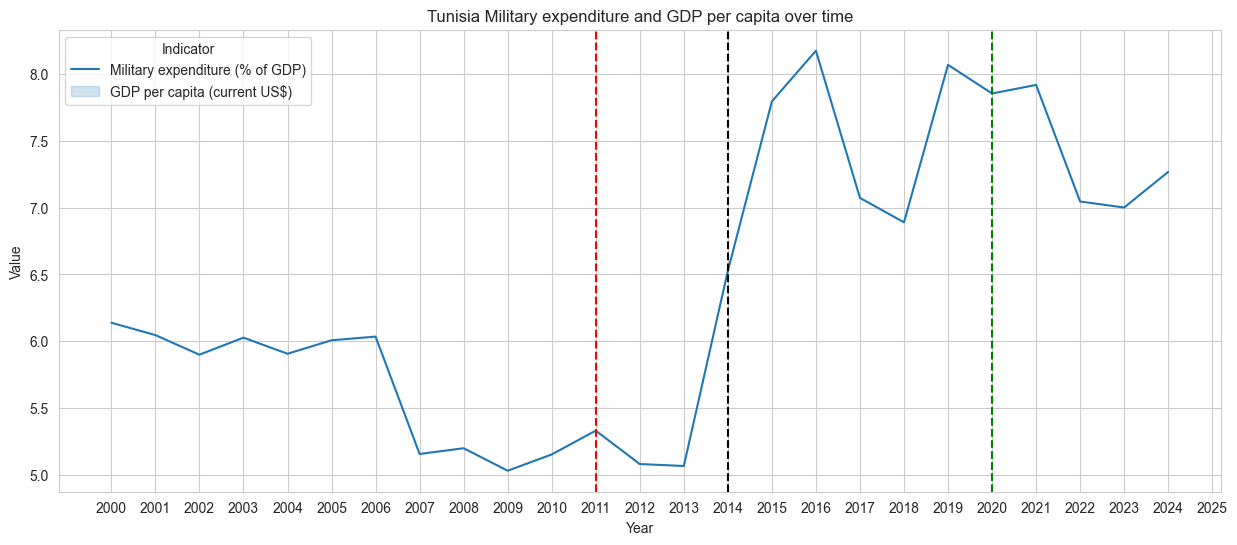

In [31]:
#military expenditure vs gdp per capita
plt.figure(figsize=(15,6))
data = tunisia_data.loc["military_expenditure"]["2000":]
sns.lineplot(data=data)
plt.axvline(x="2011", color='red', linestyle='--')
plt.axvline(x="2014", color='black', linestyle='--')
plt.axvline(x="2020", color='green', linestyle='--')
plt.title("Tunisia Military expenditure and GDP per capita over time")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend(title="Indicator", labels=["Military expenditure (% of GDP)", "GDP per capita (current US$)"])
plt.savefig("../graphs/military_expenditure_vs_gdp.png")

Following the terrorist attacks, military spending rose to an all time high. The government's priorities shifted keeping the country safe became the immediate concern, and economic recovery took a back seat. This reallocation of resources had a direct cost: less budget available for investment, infrastructure, or social spending.

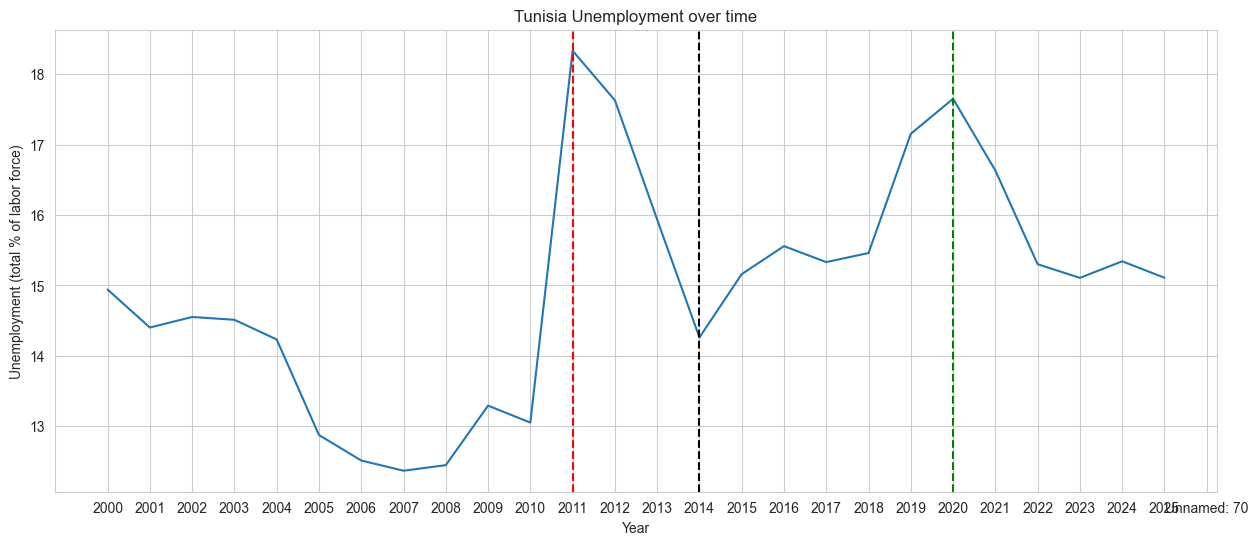

In [32]:
# unemployment 
plt.figure(figsize=(15,6))

data = tunisia_data.loc["unemployment"]["2000":]
sns.lineplot(data=data)
plt.axvline(x="2011", color='red', linestyle='--')
plt.axvline(x="2014", color='black', linestyle='--')
plt.axvline(x="2020", color='green', linestyle='--')
plt.title("Tunisia Unemployment over time")
plt.xlabel("Year")
plt.ylabel("Unemployment (total % of labor force)")
plt.savefig("../graphs/unemployment.png")



The collapse in tourism also triggered a wave of layoffs across the sector. Hotels, restaurants, transport companies, and tour operators all took heavy losses. Many small businesses went bankrupt, pushing unemployment even higher at a time when the economy could least afford it.

Text(0, 0.5, 'Inflation (annual %)')

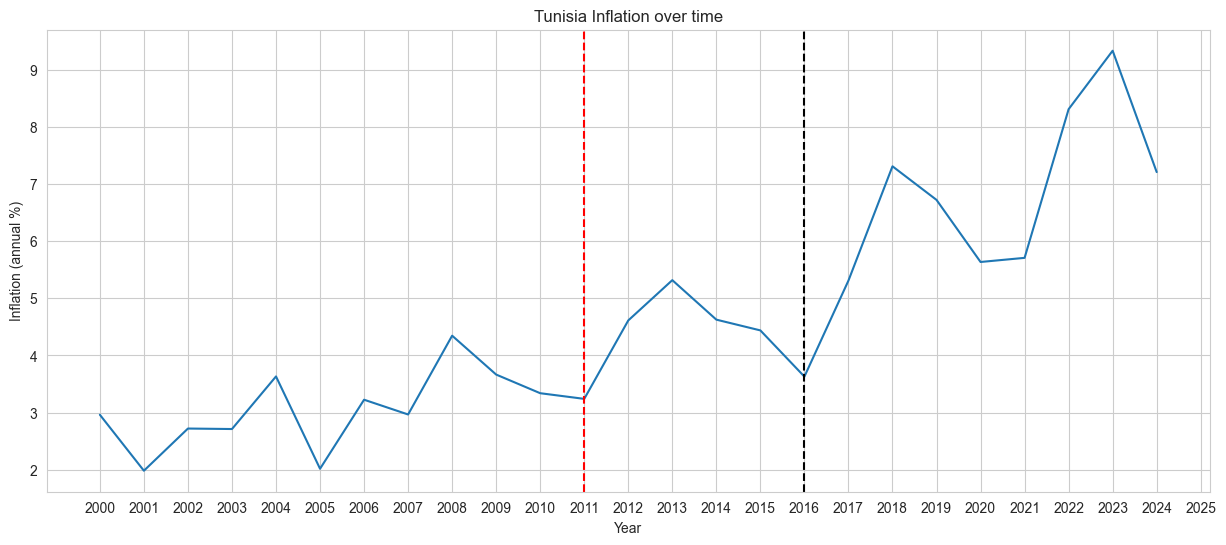

In [34]:
plt.figure(figsize=(15,6))
data = tunisia_data.loc["inflation"]["2000":] 
sns.lineplot(data=data)
plt.axvline(x="2011", color='red', linestyle='--')
plt.axvline(x="2016", color='black', linestyle='--')
plt.title("Tunisia Inflation over time")   
plt.xlabel("Year")
plt.ylabel("Inflation (annual %)")

## Chapter 4 :The Economic Spiral (2016–2023)

In 2016, Tunisia turned to the IMF for a major loan and it came with conditions. One of the key requirements was making the exchange rate more flexible. The dinar, which had been partially managed, was allowed to float more freely. The result was significant: since Tunisia imports far more than it exports, there was little demand for the dinar on international markets, and its value fell sharply against the euro. A weaker dinar meant imported goods became more expensive, and Tunisian consumers paid the price directly through rising inflation.

Text(0, 0.5, 'Health expenditure (% of GDP)')

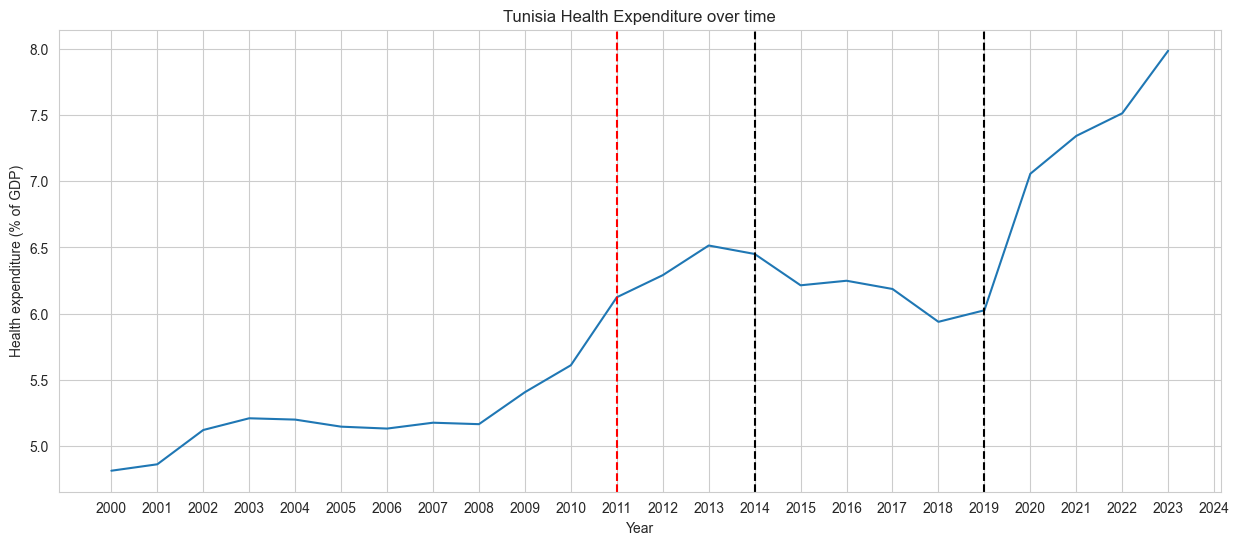

In [35]:
# health expenditure
plt.figure(figsize=(15,6))
data = tunisia_data.loc["health_expenditure"]["2000":]
sns.lineplot(data=data)
plt.axvline(x="2011", color='red', linestyle='--')
plt.axvline(x="2014", color='black', linestyle='--')
plt.axvline(x="2019", color='black', linestyle='--')
plt.title("Tunisia Health Expenditure over time")
plt.xlabel("Year")
plt.ylabel("Health expenditure (% of GDP)")


As the chart shows, health expenditure kept rising after 2011. However, after 2013 the security crisis forced the government to redirect resources toward defense, slowing that growth. The spike visible around 2019–2020 reflects the COVID-19 pandemic, which forced emergency investment in the health system.

Text(0, 0.5, 'Education expenditure (% of GDP)')

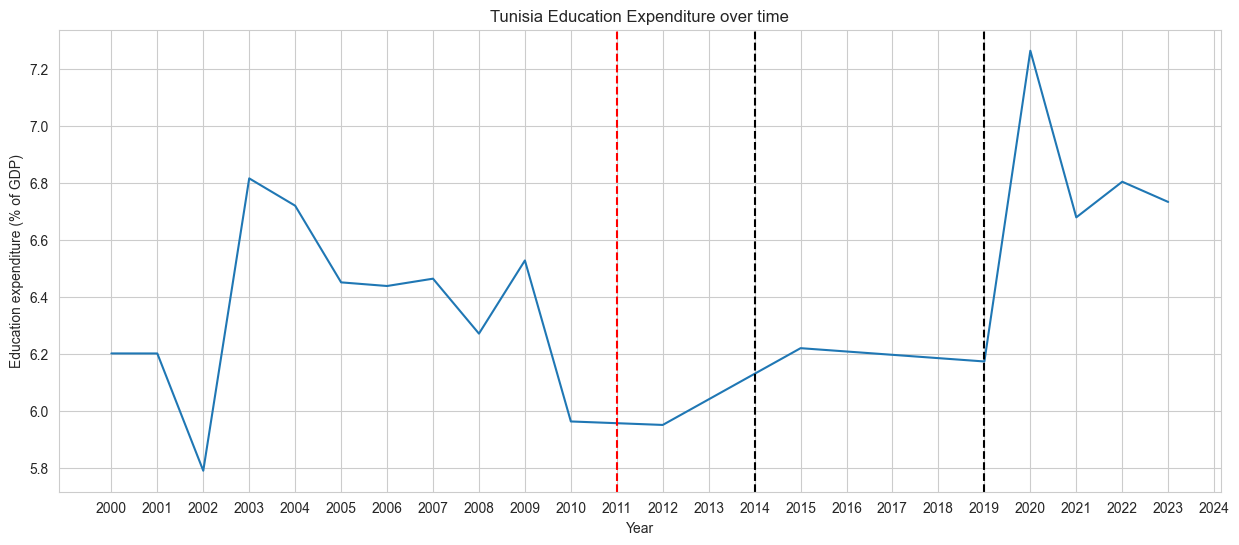

In [36]:
#education expenditure
plt.figure(figsize=(15,6))
data = tunisia_data.loc["education_expenditure"]["2000":]
sns.lineplot(data=data)
plt.axvline(x="2011", color='red', linestyle='--')
plt.axvline(x="2014", color='black', linestyle='--')
plt.axvline(x="2019", color='black', linestyle='--')
plt.title("Tunisia Education Expenditure over time")
plt.xlabel("Year")
plt.ylabel("Education expenditure (% of GDP)")


Education spending, on the other hand, doesn't follow a clear trend. There is a noticeable increase after 2019, which aligns with Kais Saied's campaign promises around public education but like most previous administrations, the commitment remained inconsistent over time.